## Build a framework for making neural nets

### Task 1: Make a class for an object that can do implement the basic neuron and calculate gradients
The basic neuron is of the form:

$f\left(\displaystyle\sum_{i}{x_i w_i} + b\right)$

where $f(a)$ is a non-linear function whose output should be constrained between $[-1, 1]$, something like the $\tanh$ function.

In [3]:
%load_ext autoreload
%aimport value
%autoreload 1

In [4]:
from value import Value
from drawNodes import draw_dot

In [5]:
a = Value(1.0); a.label = 'a'
b = Value(3.0); b.label = 'b'

c = a*b; c.label = 'c'
c.backward()

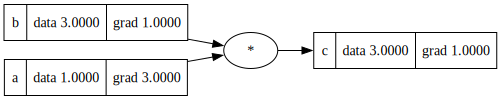

In [6]:
draw_dot(c)

In [7]:
x = Value(2.5); x.label = 'x'
y = Value(5.9); y.label = 'y'

z :Value = y * (x + 2)**1.5 -6.3 ; z.label = 'z'

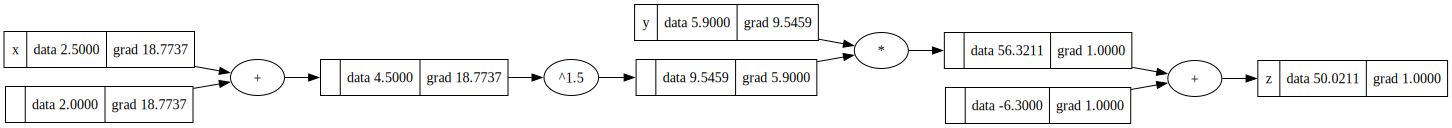

In [10]:
draw_dot(z)

In [9]:
z.backward()

In [20]:
j = Value(0.8814); j.label = 'j'
k = j.tanh(); k.label = 'k'
k.backward()

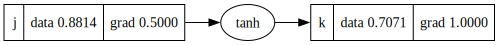

In [21]:
draw_dot(k)

In [31]:
import random

class Neuron:
    def __init__(self, n_in: int):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_in)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x: list[int | float | Value]):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, n_in: int, n_out: int):
        self.neurons = [Neuron(n_in) for _ in range(n_out)]
    
    def __call__(self, x: list[int | float | Value]):
        outs = [n(x) for n in self.neurons]
        return outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, n_in: int, n_outs: list[int]):
        sz = [n_in] + n_outs
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(sz) - 1)]
    
    def __call__(self, x: list[int | float | Value]):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [34]:
x = [2.0, 7.9, 5.5]

net = MLP(3, [4, 4, 1])
net(x)

[Value(data=0.06552256613851479)]

In [36]:
len(net.parameters())

41